In [51]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import models

In [ ]:

# measured flow rates

flow_rate = [1.0,1.0,1.0,1.5,1.5,1.5,2.0,2.0,2.0,2.5,2.5,2.5,3.0,3.0,3.0,3.5,3.5,3.5]


# measured D[4][3]
mean_diam = [246.732009888, 254.487854004, 491.828399658, 223.744995117, 224.220703125, 264.848388672, 208.161270142, 205.336929321, 207.444290161, 183.372817993, 194.926208496, 196.15486145, 190.567977905, 185.640396118, 185.924209595, 177.642791748, 179.428756714, 189.039291382]


print(len(flow_rate), len(mean_diam))

18 18


In [ ]:
# Guess for error in flow rate from our pump
err_flow_rate = [0.001]*18

#  measured error in D[4][3]
err_mean_diam = [31.3087768555, 34.9372062683, 83.3335037231, 27.0913772583, 25.5417251587, 35.0732040405, 22.5985832214, 22.151676178, 22.7422027588, 12.8472681046, 20.1266422272, 18.5341129303, 17.6065826416, 15.8278179169, 17.3750839233, 15.3873662949, 16.3185844421, 16.3961639404]





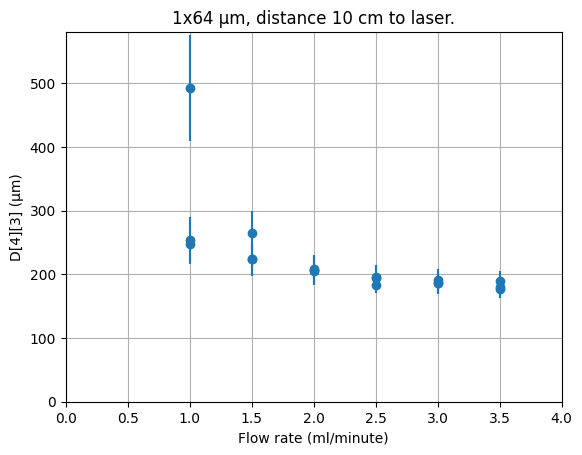

In [59]:
plt.figure()

plt.errorbar(flow_rate, mean_diam, xerr=err_flow_rate, yerr=err_mean_diam, fmt='o')

plt.title(r"1x64 μm, distance 10 cm to laser.")
plt.xlabel(r"Flow rate (ml/minute)")
plt.ylabel(r"D[4][3] (μm)")

plt.xlim(0, 4)
plt.ylim(0, 580)

plt.grid(True)

## Fitting

In [55]:
def fit_function1(x_fit, p1, p2, p3 ):
    mean_diam = p2*x_fit**p1 + p3
    return mean_diam


fit_model1 = models.Model(fit_function1)

err_mean_diam_array = np.array(err_mean_diam)
err_mean_diam_inv = 1 / err_mean_diam_array

fit_result = fit_model1.fit(mean_diam, x_fit=np.array(flow_rate), weights=err_mean_diam_inv, p1=1, p2=1, p3=1)


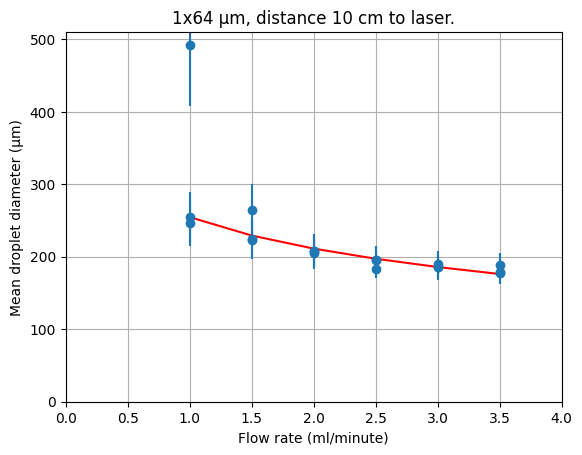

In [56]:

plt.figure()

plt.errorbar(flow_rate, mean_diam, xerr=err_flow_rate, yerr=err_mean_diam, fmt='o')
plt.plot(flow_rate, fit_result.best_fit, 'r-')


plt.title(r"1x64 μm, distance 10 cm to laser.")
plt.xlabel(r"Flow rate (ml/minute)")
plt.ylabel(r"Mean droplet diameter (μm)")

plt.xlim(0, 4)
plt.ylim(0, 510)

plt.grid(True)


In [57]:
print(fit_result.fit_report())

[[Model]]
    Model(fit_function1)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 3106
    # data points      = 18
    # variables        = 3
    chi-square         = 11.3124925
    reduced chi-square = 0.75416617
    Akaike info crit   = -2.36035400
    Bayesian info crit = 0.31076127
    R-squared          = 0.34296658
[[Variables]]
    p1:  2.6591e-05 +/- 1.24279235 (4673752.62%) (init = 1)
    p2: -2357072.26 +/- 1.0943e+11 (4642693.17%) (init = 1)
    p3:  2357326.99 +/- 1.0943e+11 (4642191.47%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(p2, p3) = -1.0000
    C(p1, p2) = +1.0000
    C(p1, p3) = -1.0000
